# 2 · Differentialrechnung und Gradientenverfahren

**Reihe:** Mathematische Grundlagen des Maschinellen Lernens · Notebook 2 von 5
**Voraussetzungen:** Analysis II (mehrdimensionale Differentialrechnung), Notebook 1
**Bearbeitungszeit:** ca. 75 Minuten

---

### Zusammenfassung

Das Training praktisch aller parametrischen Modelle ist ein Optimierungsproblem, das mit
Gradientenverfahren gelöst wird. Dieses Notebook entwickelt das Verfahren von seiner analytischen
Grundlage her: Wir zeigen mit der Cauchy–Schwarz-Ungleichung, dass der negative Gradient die
Richtung des steilsten Abstiegs ist, quantifizieren die Genauigkeit numerischer Ableitungen
einschließlich des unvermeidlichen Abbruch-Rundungsfehler-Kompromisses und beweisen für
quadratische Zielfunktionen exakte Konvergenzbedingungen an die Schrittweite. Anschließend
übertragen wir die Analyse auf $L$-glatte konvexe Funktionen, identifizieren die Konditionszahl
als den Faktor, der die Konvergenzgeschwindigkeit bestimmt, und zeigen, wie das
Impulsverfahren diese Abhängigkeit von $\kappa$ auf $\sqrt{\kappa}$ reduziert.

### Lernziele

Nach Bearbeitung dieses Notebooks können Sie

1. Richtungsableitung, Gradient und Hesse-Matrix formal auseinanderhalten und begründen, warum
   $-\nabla f$ die steilste Abstiegsrichtung ist;
2. die Fehlerordnung von Vorwärts- und Zentraldifferenz herleiten und die optimale Schrittweite
   $h$ aus dem Zusammenspiel von Abbruch- und Rundungsfehler bestimmen;
3. für $f(x) = \tfrac{a}{2}x^2$ exakt angeben, für welche Lernraten das Gradientenverfahren
   konvergiert, oszilliert oder divergiert;
4. das Abstiegslemma für $L$-glatte Funktionen beweisen und die Konvergenzraten
   $\mathcal{O}(1/k)$ bzw. $\mathcal{O}((1-\mu/L)^k)$ einordnen;
5. den Einfluss der Konditionszahl $\kappa$ auf das Konvergenzverhalten empirisch nachweisen;
6. erklären, weshalb das Impulsverfahren die Iterationszahl von $\mathcal{O}(\kappa)$ auf
   $\mathcal{O}(\sqrt{\kappa})$ senkt.

### Inhalt

1. [Gradient, Richtungsableitung und Taylor-Entwicklung](#1)
2. [Numerische Differentiation](#2)
3. [Das Gradientenverfahren im quadratischen Fall](#3)
4. [Konvergenz für $L$-glatte konvexe Funktionen](#4)
5. [Konditionszahl und Anisotropie](#5)
6. [Impulsverfahren](#6)
7. [Übungsaufgaben](#7)

## 0 Vorbereitung

Die folgende Zelle lädt die Abhängigkeiten, fixiert den Zufallsgenerator und setzt
das einheitliche Abbildungslayout der Reihe. Sie ist in allen Notebooks identisch
und muss vor allen weiteren Zellen ausgeführt werden.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

# Reproduzierbarkeit: fester Seed für alle stochastischen Experimente dieses Notebooks
SEED = 20260730
rng = np.random.default_rng(SEED)

# Einheitliches Abbildungslayout für die gesamte Notebook-Reihe.
# Die Farbfolge ist auf Farbfehlsichtigkeit geprüft (Blau, Orange, Aquamarin,
# Violett, Rot); benachbarte Serien sind sowohl in der Helligkeit als auch im
# Farbton unterscheidbar.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#e34948"]

mpl.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.prop_cycle": cycler(color=PALETTE),
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.labelcolor": "#0b0b0b",
    "grid.color": "#d8d7d2",
    "grid.linewidth": 0.6,
    "legend.frameon": False,
    "lines.linewidth": 2.0,
    "font.size": 10,
    "mathtext.fontset": "cm",
})

np.set_printoptions(precision=4, suppress=True)
print(f"NumPy {np.__version__} · Matplotlib {mpl.__version__} · Seed {SEED}")

NumPy 2.4.6 · Matplotlib 3.11.1 · Seed 20260730


<a id="1"></a>
## 1 Gradient, Richtungsableitung und Taylor-Entwicklung

> **Definition 1.1 (Gradient und Hesse-Matrix).** Sei $f : \mathbb{R}^n \to \mathbb{R}$ zweimal
> stetig differenzierbar. Der *Gradient* und die *Hesse-Matrix* sind
> $$\nabla f(x) = \Big(\frac{\partial f}{\partial x_1}(x), \dots, \frac{\partial f}{\partial x_n}(x)\Big)^{\!\top},
> \qquad
> \big(\nabla^2 f(x)\big)_{ij} = \frac{\partial^2 f}{\partial x_i \partial x_j}(x).$$
> Nach dem Satz von Schwarz ist $\nabla^2 f(x)$ symmetrisch.

> **Definition 1.2 (Richtungsableitung).** Für $v \in \mathbb{R}^n$ mit $\|v\|_2 = 1$ ist
> $$D_v f(x) \;=\; \lim_{t \to 0} \frac{f(x + tv) - f(x)}{t} \;=\; \langle \nabla f(x), v\rangle,$$
> wobei die zweite Gleichheit für differenzierbares $f$ aus der Kettenregel folgt.

> **Satz 1.3 (Steilster Abstieg).** Sei $\nabla f(x) \ne 0$. Dann gilt
> $$\operatorname*{arg\,min}_{\|v\|_2 = 1} D_v f(x) \;=\; -\frac{\nabla f(x)}{\|\nabla f(x)\|_2},
> \qquad \text{mit } \min_{\|v\|_2=1} D_v f(x) = -\|\nabla f(x)\|_2 .$$
>
> *Beweis.* Nach Cauchy–Schwarz (Satz 3.2 in Notebook 1) ist
> $\lvert\langle \nabla f(x), v\rangle\rvert \le \|\nabla f(x)\|_2 \|v\|_2 = \|\nabla f(x)\|_2$,
> also $D_v f(x) \ge -\|\nabla f(x)\|_2$ für alle Einheitsvektoren $v$. Gleichheit tritt genau bei
> linearer Abhängigkeit ein, hier also für $v = -\nabla f(x)/\|\nabla f(x)\|_2$. $\square$

Beachten Sie die Voraussetzung $\|v\|_2 = 1$: Der steilste Abstieg ist *relativ zur euklidischen
Norm* definiert. Misst man die Schrittlänge in einer anderen Norm, ergibt sich eine andere
Richtung — genau hier setzen vorkonditionierte Verfahren und das Newton-Verfahren an
(Aufgabe 2.4).

> **Satz 1.4 (Taylor, zweite Ordnung).** Ist $f$ zweimal stetig differenzierbar, so gilt
> $$f(x + d) \;=\; f(x) + \langle \nabla f(x), d\rangle + \tfrac{1}{2}\, d^\top \nabla^2 f(x)\, d
> + o(\|d\|_2^2) \qquad (d \to 0).$$

Das Gradientenverfahren minimiert in jedem Schritt das *lineare* Modell aus Satz 1.4 unter einer
Schrittweitenbeschränkung; Newton-artige Verfahren nutzen zusätzlich den quadratischen Term.

In [2]:
def rosenbrock(x):
    """Rosenbrock-Funktion, ein Standardtestproblem mit gekrümmtem, flachem Tal."""
    return (1.0 - x[0]) ** 2 + 100.0 * (x[1] - x[0] ** 2) ** 2


def rosenbrock_grad(x):
    return np.array([
        -2.0 * (1.0 - x[0]) - 400.0 * x[0] * (x[1] - x[0] ** 2),
        200.0 * (x[1] - x[0] ** 2),
    ])


# Satz 1.3 empirisch: unter allen Einheitsrichtungen minimiert -grad/||grad|| die
# Richtungsableitung, und der erreichte Wert ist genau -||grad||.
x0 = np.array([-0.8, 1.4])
g = rosenbrock_grad(x0)

theta = np.linspace(0, 2 * np.pi, 2000)
V = np.stack([np.cos(theta), np.sin(theta)], axis=1)
directional = V @ g

best = V[np.argmin(directional)]
steepest = -g / np.linalg.norm(g)

print(f"Gradient           : {g}")
print(f"beste Richtung (Suche): {best}")
print(f"-grad/||grad||        : {steepest}")
print(f"Winkelabweichung      : {np.degrees(np.arccos(np.clip(best @ steepest, -1, 1))):.4f}°")
print(f"\nmin_v D_v f(x) = {directional.min():.6f}   vs.   -||grad|| = {-np.linalg.norm(g):.6f}")

Gradient           : [239.6 152. ]
beste Richtung (Suche): [-0.845  -0.5347]
-grad/||grad||        : [-0.8444 -0.5357]
Winkelabweichung      : 0.0645°

min_v D_v f(x) = -283.746468   vs.   -||grad|| = -283.746648


<a id="2"></a>
## 2 Numerische Differentiation

Analytische Gradienten sind nicht immer verfügbar; zugleich ist die numerische Ableitung das
Standardwerkzeug, um eine analytisch hergeleitete Implementierung zu prüfen (*gradient checking*).
Aus der Taylor-Entwicklung folgen die beiden gebräuchlichen Formeln.

> **Satz 2.1 (Fehlerordnung).** Sei $f$ hinreichend oft stetig differenzierbar. Dann gilt
> $$\underbrace{\frac{f(x+h) - f(x)}{h}}_{\text{Vorwärtsdifferenz}} = f'(x) + \frac{h}{2}f''(x) + \mathcal{O}(h^2),
> \qquad
> \underbrace{\frac{f(x+h) - f(x-h)}{2h}}_{\text{Zentraldifferenz}} = f'(x) + \frac{h^2}{6}f'''(x) + \mathcal{O}(h^4).$$
>
> *Beweis.* Einsetzen von $f(x\pm h) = f(x) \pm hf'(x) + \tfrac{h^2}{2}f''(x) \pm \tfrac{h^3}{6}f'''(x) + \dots$
> Bei der Zentraldifferenz heben sich die geraden Terme auf, weshalb die Ordnung von $1$ auf $2$
> steigt. $\square$

Der *Abbruchfehler* fällt also mit $h$. In endlicher Arithmetik kommt jedoch ein
**Rundungsfehler** hinzu: Die Auswertung von $f$ ist nur bis auf $\varepsilon_{\text{mach}}|f(x)|$
genau, und die Differenzbildung im Zähler verstärkt diesen Fehler um $1/h$. Für den Gesamtfehler
gilt daher näherungsweise
$$E(h) \;\approx\; \underbrace{C\,h^{\,q}}_{\text{Abbruch}} \;+\; \underbrace{\frac{\varepsilon_{\text{mach}}\,|f(x)|}{h}}_{\text{Rundung}},
\qquad q \in \{1,2\}.$$
Minimieren nach $h$ liefert
$$h^\ast_{\text{vorwärts}} \sim \sqrt{\varepsilon_{\text{mach}}} \approx 1{,}5\cdot 10^{-8},
\qquad
h^\ast_{\text{zentral}} \sim \sqrt[3]{\varepsilon_{\text{mach}}} \approx 6\cdot 10^{-6},$$
mit zugehörigen minimalen Fehlern von $\mathcal{O}(\sqrt{\varepsilon_{\text{mach}}})$ bzw.
$\mathcal{O}(\varepsilon_{\text{mach}}^{2/3})$. **Ein kleineres $h$ ist also nicht besser** —
eine der praktisch folgenreichsten Aussagen der numerischen Mathematik.

In [3]:
def forward_difference(f, x, h):
    return (f(x + h) - f(x)) / h


def central_difference(f, x, h):
    return (f(x + h) - f(x - h)) / (2.0 * h)


def complex_step(f, x, h):
    """Komplexer Schritt: Im f(x + ih)/h = f'(x) + O(h^2), ohne Differenzbildung
    und damit ohne Ausloeschung. Setzt voraus, dass f komplex auswertbar und
    holomorph ist (Bemerkung 2.2)."""
    return np.imag(f(x + 1j * h)) / h


f, df = np.sin, np.cos
x_eval = 1.2
exact = df(x_eval)

h_values = np.logspace(-16, -1, 200)
errors = {
    "Vorwärtsdifferenz": np.abs(forward_difference(f, x_eval, h_values) - exact),
    "Zentraldifferenz": np.abs(central_difference(f, x_eval, h_values) - exact),
    "komplexer Schritt": np.abs(complex_step(f, x_eval, h_values) - exact),
}

eps = np.finfo(float).eps
for name, err in errors.items():
    i = int(np.argmin(err))
    print(f"{name:<20} kleinster Fehler {err[i]:.3e} bei h = {h_values[i]:.2e}")
print(f"\nTheoretische Optima: h_vorwaerts ~ sqrt(eps) = {np.sqrt(eps):.2e}, "
      f"h_zentral ~ eps^(1/3) = {eps ** (1 / 3):.2e}")

Vorwärtsdifferenz    kleinster Fehler 4.870e-10 bei h = 1.16e-08
Zentraldifferenz     kleinster Fehler 1.548e-12 bei h = 7.15e-06
komplexer Schritt    kleinster Fehler 0.000e+00 bei h = 1.00e-16

Theoretische Optima: h_vorwaerts ~ sqrt(eps) = 1.49e-08, h_zentral ~ eps^(1/3) = 6.06e-06


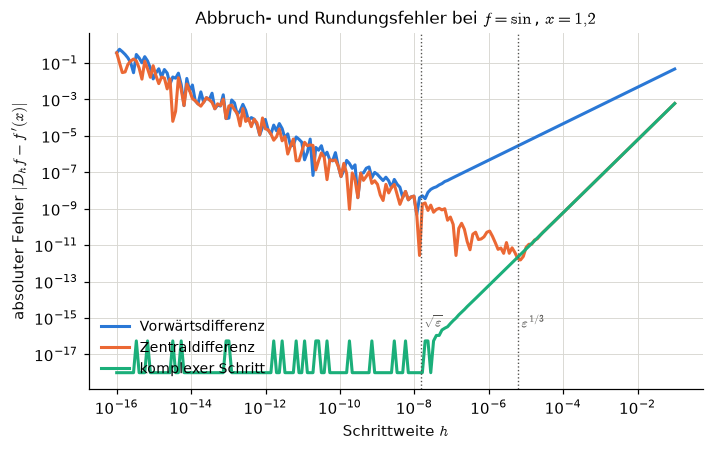

Vorwärtsdifferenz    empirische Ordnung q = 1.001
Zentraldifferenz     empirische Ordnung q = 2.000


In [4]:
fig, ax = plt.subplots()
for (name, err), color in zip(errors.items(), PALETTE):
    ax.loglog(h_values, np.maximum(err, 1e-18), label=name, color=color)

for h_star, label in [(np.sqrt(eps), r"$\sqrt{\varepsilon}$"), (eps ** (1 / 3), r"$\varepsilon^{1/3}$")]:
    ax.axvline(h_star, color="#52514e", linewidth=0.9, linestyle=":")
    ax.text(h_star * 1.25, 3e-16, label, fontsize=9, color="#52514e")

ax.set_xlabel("Schrittweite $h$")
ax.set_ylabel(r"absoluter Fehler $|D_h f - f'(x)|$")
ax.set_title(r"Abbruch- und Rundungsfehler bei $f=\sin$, $x=1{,}2$")
ax.legend(loc="lower left", fontsize=9)
plt.show()

# Empirische Ordnung im abbruchdominierten Bereich (grosse h)
regime = (h_values > 1e-4) & (h_values < 1e-1)
for name in ("Vorwärtsdifferenz", "Zentraldifferenz"):
    slope = np.polyfit(np.log(h_values[regime]), np.log(errors[name][regime]), 1)[0]
    print(f"{name:<20} empirische Ordnung q = {slope:.3f}")

**Abbildung 2.1** — Fehler der Differenzenquotienten über der Schrittweite. Von rechts kommend
fällt der Abbruchfehler mit Steigung $1$ (Vorwärts-) bzw. $2$ (Zentraldifferenz); links des
Minimums steigt der Rundungsfehler mit Steigung $-1$. Die gepunkteten Linien markieren die
theoretischen Optima.

> **Bemerkung 2.2 (Komplexer Schritt).** Ist $f$ holomorph, so folgt aus
> $f(x + ih) = f(x) + ihf'(x) - \tfrac{h^2}{2}f''(x) + \mathcal{O}(h^3)$ sofort
> $$f'(x) = \frac{\operatorname{Im} f(x + ih)}{h} + \mathcal{O}(h^2).$$
> Hier wird **keine Differenz gebildet**, es tritt also keine Auslöschung auf: Der Fehler fällt
> monoton mit $h^2$ bis auf Maschinengenauigkeit — in Abbildung 2.1 die Kurve ohne
> Rundungsfehleranstieg. Das Verfahren ist die numerisch saubere Variante des *gradient checking*,
> setzt aber eine komplex auswertbare Implementierung voraus.

<a id="3"></a>
## 3 Das Gradientenverfahren im quadratischen Fall

> **Algorithmus 3.1 (Gradientenverfahren).**
> Gegeben $x_0 \in \mathbb{R}^n$, Lernrate $\eta > 0$, Toleranz $\tau > 0$.
> Für $k = 0, 1, 2, \dots$:
> $$x_{k+1} \;=\; x_k - \eta\, \nabla f(x_k),$$
> Abbruch, sobald $\|\nabla f(x_k)\|_2 \le \tau$.

Der eindimensionale quadratische Fall lässt sich vollständig durchrechnen und erklärt bereits
alle qualitativen Verhaltensweisen des Verfahrens.

> **Satz 3.2.** Sei $f(x) = \tfrac{a}{2}x^2$ mit $a > 0$, also $f'(x) = a x$ und $x^\ast = 0$.
> Dann erzeugt Algorithmus 3.1 die Folge
> $$x_k \;=\; (1 - \eta a)^k\, x_0 .$$
> Folglich gilt:
>
> | Lernrate | Verhalten |
> |---|---|
> | $0 < \eta < 1/a$ | monotone Konvergenz |
> | $\eta = 1/a$ | Konvergenz in **einem** Schritt |
> | $1/a < \eta < 2/a$ | alternierende (oszillierende) Konvergenz |
> | $\eta = 2/a$ | periodische Oszillation, keine Konvergenz |
> | $\eta > 2/a$ | Divergenz |
>
> *Beweis.* $x_{k+1} = x_k - \eta a x_k = (1-\eta a)x_k$; Induktion liefert die geschlossene Form.
> Die Folge konvergiert genau dann gegen $0$, wenn $\lvert 1 - \eta a\rvert < 1$, also
> $0 < \eta < 2/a$. Das Vorzeichen von $1-\eta a$ entscheidet über Monotonie oder Alternanz. $\square$

Der Faktor $\lvert 1-\eta a\rvert$ heißt *Kontraktionsfaktor*. Er ist genau dann minimal (nämlich
null), wenn $\eta = 1/a$ — die Lernrate ist also nicht „so klein wie möglich“ zu wählen, sondern
an die Krümmung anzupassen.

In [5]:
def gradient_descent(grad, x0, lr, n_steps=200, tol=1e-10, momentum=0.0, nesterov=False):
    """Gradientenverfahren mit optionalem Polyak- bzw. Nesterov-Impuls.

    Rueckgabe: Array der Iterierten mit Form (k+1, n); die Iteration bricht ab,
    sobald ||grad|| <= tol oder die Iterierte numerisch entgleist."""
    x = np.atleast_1d(np.asarray(x0, dtype=float)).copy()
    v = np.zeros_like(x)
    history = [x.copy()]
    for _ in range(n_steps):
        g = grad(x + momentum * v) if nesterov else grad(x)
        if not np.all(np.isfinite(g)) or np.linalg.norm(g) > 1e12:
            break
        v = momentum * v - lr * g
        x = x + v
        history.append(x.copy())
        if np.linalg.norm(g) <= tol:
            break
    return np.array(history)


a, x_start = 2.0, 4.0          # f(x) = (a/2) x^2, Minimum bei x* = 0
regimes = [
    (0.10, "$\\eta = 0{,}10 < 1/a$: monoton"),
    (0.50, "$\\eta = 1/a$: ein Schritt"),
    (0.90, "$1/a < \\eta < 2/a$: oszillierend"),
    (1.05, "$\\eta > 2/a$: divergent"),
]

print(f"a = {a},  1/a = {1 / a},  2/a = {2 / a}\n")
print(f"{'eta':>6} | {'|1-eta*a|':>10} | {'|x_20|':>12} | Verhalten")
print("-" * 62)
for lr, label in regimes:
    hist = gradient_descent(lambda x: a * x, [x_start], lr, n_steps=20)
    factor = abs(1 - lr * a)
    print(f"{lr:>6.2f} | {factor:>10.3f} | {abs(hist[-1, 0]):>12.3e} | "
          f"{'konvergent' if factor < 1 else 'divergent'}")

a = 2.0,  1/a = 0.5,  2/a = 1.0

   eta |  |1-eta*a| |       |x_20| | Verhalten
--------------------------------------------------------------
  0.10 |      0.800 |    4.612e-02 | konvergent
  0.50 |      0.000 |    0.000e+00 | konvergent
  0.90 |      0.800 |    4.612e-02 | konvergent
  1.05 |      1.100 |    2.691e+01 | divergent


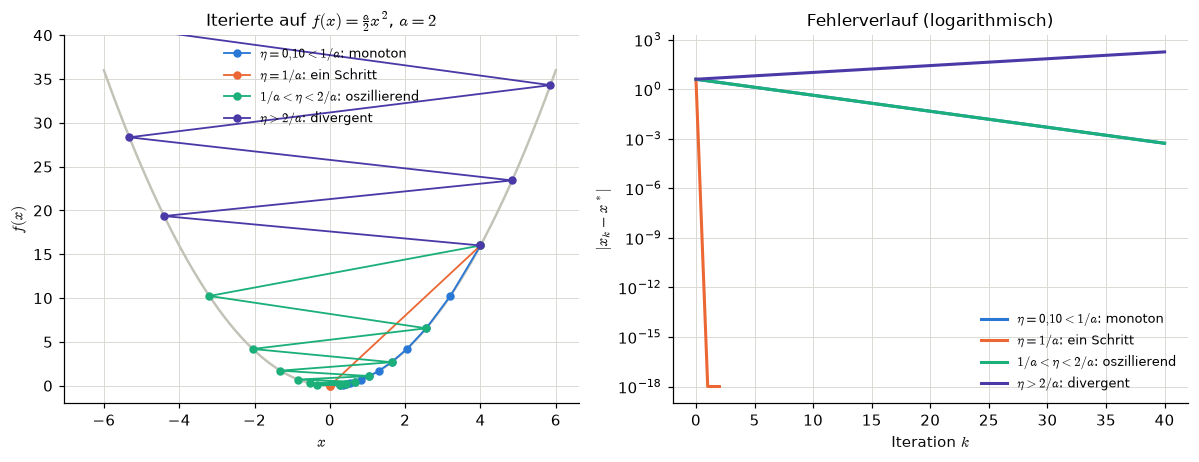

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.3))

grid = np.linspace(-6, 6, 400)
axes[0].plot(grid, 0.5 * a * grid ** 2, color="#c3c2b7", linewidth=1.6, zorder=1)
for (lr, label), color in zip(regimes, PALETTE):
    hist = gradient_descent(lambda x: a * x, [x_start], lr, n_steps=12)[:, 0]
    hist = hist[np.abs(hist) < 6.5]
    axes[0].plot(hist, 0.5 * a * hist ** 2, marker="o", markersize=4.5,
                 linewidth=1.2, color=color, label=label)
    steps = np.arange(len(gradient_descent(lambda x: a * x, [x_start], lr, n_steps=40)))
    axes[1].semilogy(steps,
                     np.maximum(np.abs(gradient_descent(lambda x: a * x, [x_start], lr,
                                                        n_steps=40)[:, 0]), 1e-18),
                     color=color, label=label)

axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$f(x)$")
axes[0].set_title(r"Iterierte auf $f(x) = \frac{a}{2}x^2$, $a=2$")
axes[0].set_ylim(-2, 40)
axes[0].legend(fontsize=8.5, loc="upper center")

axes[1].set_xlabel("Iteration $k$")
axes[1].set_ylabel(r"$|x_k - x^\ast|$")
axes[1].set_title("Fehlerverlauf (logarithmisch)")
axes[1].legend(fontsize=8.5)

plt.tight_layout()
plt.show()

**Abbildung 2.2** — Links die Iterierten auf der Parabel, rechts der Fehler über der Iteration.
Im halblogarithmischen Diagramm ist die geometrische Konvergenz an der Geradenform erkennbar; die
Steigung ist $\log\lvert 1-\eta a\rvert$. Für $\eta = 1/a$ bricht die Kurve nach einem Schritt auf
Maschinengenauigkeit ein, für $\eta > 2/a$ steigt sie linear an — die Divergenz ist ebenfalls
geometrisch.

<a id="4"></a>
## 4 Konvergenz für $L$-glatte konvexe Funktionen

Die quadratische Analyse verallgemeinert sich auf eine breite Funktionenklasse.

> **Definition 4.1.** $f : \mathbb{R}^n \to \mathbb{R}$ heißt
> * *$L$-glatt*, wenn $\nabla f$ Lipschitz-stetig mit Konstante $L$ ist:
>   $\|\nabla f(x) - \nabla f(y)\|_2 \le L\|x-y\|_2$;
> * *$\mu$-stark konvex*, wenn $f(y) \ge f(x) + \langle \nabla f(x), y-x\rangle + \tfrac{\mu}{2}\|y-x\|_2^2$
>   für alle $x,y$ gilt.
>
> Für zweimal differenzierbares $f$ ist beides äquivalent zu
> $\mu I \preceq \nabla^2 f(x) \preceq L I$. Der Quotient $\kappa = L/\mu \ge 1$ heißt
> *Konditionszahl* des Problems.

> **Satz 4.2 (Abstiegslemma).** Ist $f$ $L$-glatt, so gilt für $x^+ = x - \eta\nabla f(x)$
> $$f(x^+) \;\le\; f(x) - \eta\Big(1 - \frac{L\eta}{2}\Big)\,\|\nabla f(x)\|_2^2 .$$
> Insbesondere ist der Abstieg für $0 < \eta < 2/L$ echt, und $\eta = 1/L$ maximiert die
> garantierte Verbesserung zu $f(x^+) \le f(x) - \tfrac{1}{2L}\|\nabla f(x)\|_2^2$.
>
> *Beweis.* Aus der $L$-Glattheit folgt die quadratische obere Schranke
> $f(y) \le f(x) + \langle\nabla f(x), y-x\rangle + \tfrac{L}{2}\|y-x\|_2^2$ (Standardresultat,
> etwa Nesterov 2004, Lemma 1.2.3). Einsetzen von $y = x^+$, also $y - x = -\eta\nabla f(x)$:
> $$f(x^+) \le f(x) - \eta\|\nabla f(x)\|^2 + \frac{L\eta^2}{2}\|\nabla f(x)\|^2
> = f(x) - \eta\Big(1-\frac{L\eta}{2}\Big)\|\nabla f(x)\|^2 . \qquad \square$$

> **Satz 4.3 (Konvergenzraten).** Sei $f$ $L$-glatt und $\eta = 1/L$.
> * Ist $f$ konvex mit Minimalstelle $x^\ast$, so gilt
>   $\; f(x_k) - f(x^\ast) \le \dfrac{L\,\|x_0 - x^\ast\|_2^2}{2k} = \mathcal{O}(1/k)$.
> * Ist $f$ zusätzlich $\mu$-stark konvex, so gilt
>   $\; \|x_k - x^\ast\|_2^2 \le \Big(1 - \dfrac{1}{\kappa}\Big)^{k}\|x_0 - x^\ast\|_2^2$,
>   also **lineare** (geometrische) Konvergenz.
>
> Beweise: Nesterov (2004), Sätze 2.1.14 und 2.1.15.

Der Unterschied ist praktisch gravierend: Für eine Genauigkeit $\epsilon$ benötigt der konvexe
Fall $\mathcal{O}(1/\epsilon)$ Iterationen, der stark konvexe nur
$\mathcal{O}(\kappa \log(1/\epsilon))$.

In [7]:
# (a) stark konvex: f(x) = 1/2 x^T A x mit A = diag(1, 10)  ->  mu = 1, L = 10
A = np.diag([1.0, 10.0])
mu, L = 1.0, 10.0
f_quad = lambda x: 0.5 * x @ A @ x
grad_quad = lambda x: A @ x

hist_quad = gradient_descent(grad_quad, [3.0, 3.0], lr=1.0 / L, n_steps=120, tol=0.0)
err_quad = np.linalg.norm(hist_quad, axis=1) ** 2
bound_quad = (1 - mu / L) ** np.arange(len(hist_quad)) * err_quad[0]

# (b) konvex, aber nicht stark konvex: f(x) = x^4  ->  Kruemmung verschwindet in x* = 0
f_quart = lambda x: x ** 4
grad_quart = lambda x: 4.0 * x ** 3

hist_quart = gradient_descent(grad_quart, [1.0], lr=0.05, n_steps=4000, tol=0.0)[:, 0]
gap_quart = f_quart(hist_quart)
k = np.arange(1, len(hist_quart) + 1)
bound_quart = 1.0 / (2 * 0.05 * k)          # O(1/k)-Schranke aus Satz 4.3

print(f"(a) stark konvex   : ||x_100 - x*||^2 = {err_quad[100]:.3e}, "
      f"Schranke = {bound_quad[100]:.3e}")
print(f"(b) nur konvex     : f(x_1000) - f*  = {gap_quart[1000]:.3e}, "
      f"Schranke = {bound_quart[1000]:.3e}")

(a) stark konvex   : ||x_100 - x*||^2 = 6.350e-09, Schranke = 4.781e-04
(b) nur konvex     : f(x_1000) - f*  = 6.161e-06, Schranke = 9.990e-03


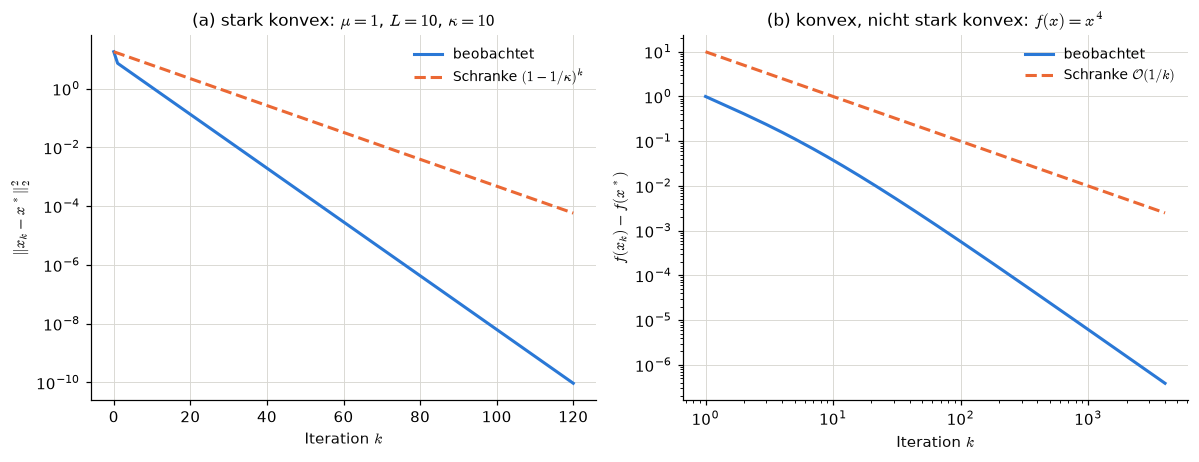

Empirische Rate in (b): f(x_k) - f* ~ k^-1.99


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.3))

axes[0].semilogy(np.maximum(err_quad, 1e-18), color=PALETTE[0], label="beobachtet")
axes[0].semilogy(bound_quad, color=PALETTE[1], linestyle="--",
                 label=r"Schranke $(1-1/\kappa)^k$")
axes[0].set_xlabel("Iteration $k$")
axes[0].set_ylabel(r"$\|x_k - x^\ast\|_2^2$")
axes[0].set_title(r"(a) stark konvex: $\mu=1$, $L=10$, $\kappa=10$")
axes[0].legend(fontsize=9)

axes[1].loglog(k, np.maximum(gap_quart, 1e-18), color=PALETTE[0], label="beobachtet")
axes[1].loglog(k, bound_quart, color=PALETTE[1], linestyle="--",
               label=r"Schranke $\mathcal{O}(1/k)$")
axes[1].set_xlabel("Iteration $k$")
axes[1].set_ylabel(r"$f(x_k) - f(x^\ast)$")
axes[1].set_title(r"(b) konvex, nicht stark konvex: $f(x)=x^4$")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

slope = np.polyfit(np.log(k[100:]), np.log(gap_quart[100:]), 1)[0]
print(f"Empirische Rate in (b): f(x_k) - f* ~ k^{slope:.2f}")

**Abbildung 2.3** — (a) Im stark konvexen Fall ist der Fehlerverlauf im halblogarithmischen
Diagramm eine Gerade: geometrische Konvergenz mit dem von Satz 4.3 vorhergesagten Faktor.
(b) Ohne starke Konvexität ist die Konvergenz im doppeltlogarithmischen Diagramm eine Gerade,
also nur polynomiell. Die $\mathcal{O}(1/k)$-Schranke wird eingehalten, ist hier aber nicht
scharf — für $f(x)=x^4$ misst man empirisch $\mathcal{O}(k^{-2})$. Worst-case-Schranken sind
Garantien, keine Prognosen für den Einzelfall.

<a id="5"></a>
## 5 Konditionszahl und Anisotropie

Für $f(x) = \tfrac12 x^\top A x$ mit symmetrisch positiv definitem $A$ entkoppelt eine
Hauptachsentransformation das Problem: In der Eigenbasis von $A$ zerfällt es in $n$ unabhängige
eindimensionale Probleme mit Krümmungen $\lambda_1, \dots, \lambda_n$. Nach Satz 3.2 muss
$\eta < 2/\lambda_{\max}$ gelten — die *größte* Krümmung begrenzt die Schrittweite, während die
*kleinste* die Konvergenzgeschwindigkeit bestimmt.

> **Satz 5.1.** Für $f(x) = \tfrac12 x^\top A x$ mit Eigenwerten
> $0 < \mu = \lambda_{\min} \le \dots \le \lambda_{\max} = L$ ist die optimale konstante Lernrate
> $$\eta^\ast = \frac{2}{\mu + L}, \qquad \text{mit Kontraktionsfaktor} \quad
> \max_i \lvert 1 - \eta^\ast \lambda_i\rvert = \frac{L-\mu}{L+\mu} = \frac{\kappa-1}{\kappa+1} .$$
>
> *Beweis.* In der Eigenbasis ist der Fehler koordinatenweise $(1-\eta\lambda_i)^k$. Zu minimieren
> ist $\max_i \lvert 1-\eta\lambda_i\rvert$ über $\eta$; das Maximum wird stets an einem der
> Randeigenwerte $\mu$ oder $L$ angenommen. Die Funktion $\eta \mapsto 1-\eta\mu$ fällt, die
> Funktion $\eta \mapsto \eta L - 1$ steigt; das Minimum des Maximums liegt daher im Schnittpunkt
> $1-\eta\mu = \eta L - 1$, also bei $\eta^\ast = 2/(\mu+L)$. Einsetzen ergibt den Faktor. $\square$

Für die Iterationszahl bis zur Genauigkeit $\epsilon$ folgt
$$k(\epsilon) \;\approx\; \frac{\log(1/\epsilon)}{-\log\frac{\kappa-1}{\kappa+1}} \;\approx\; \frac{\kappa}{2}\,\log\frac{1}{\epsilon}
\qquad (\kappa \gg 1),$$
also **lineares** Wachstum in $\kappa$. Das ist die eigentliche Ursache für den berüchtigten
Zickzack-Verlauf in schmalen Tälern.

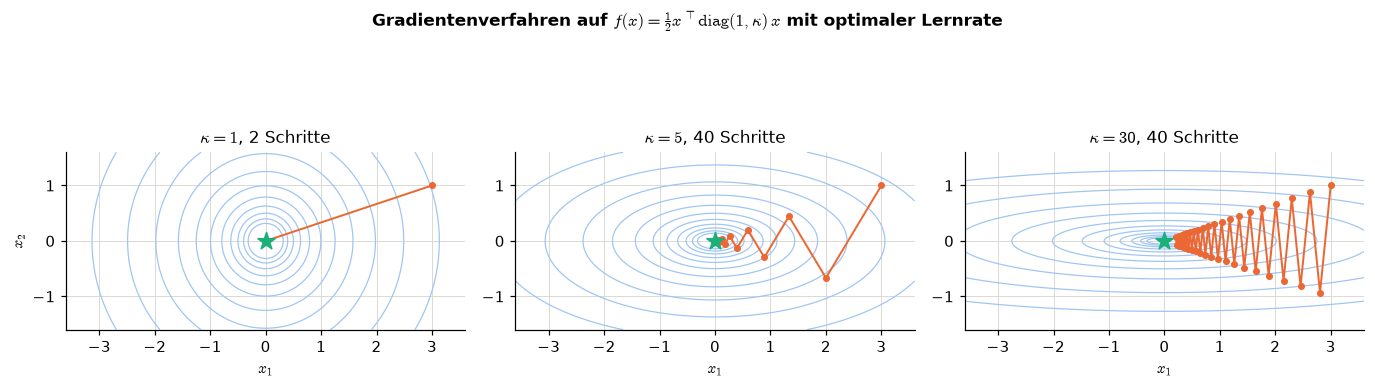

In [9]:
def quadratic_problem(kappa):
    """f(x) = 1/2 x^T diag(1, kappa) x mit Konditionszahl kappa."""
    A = np.diag([1.0, kappa])
    return (lambda x: 0.5 * x @ A @ x), (lambda x: A @ x), A


fig, axes = plt.subplots(1, 3, figsize=(12.6, 4.0))

for ax, kappa in zip(axes, [1.0, 5.0, 30.0]):
    f_k, grad_k, _ = quadratic_problem(kappa)
    eta_star = 2.0 / (1.0 + kappa)
    hist = gradient_descent(grad_k, [3.0, 1.0], lr=eta_star, n_steps=40, tol=1e-12)

    gx = np.linspace(-3.6, 3.6, 300)
    gy = np.linspace(-1.6, 1.6, 300)
    GX, GY = np.meshgrid(gx, gy)
    Z = 0.5 * (GX ** 2 + kappa * GY ** 2)

    ax.contour(GX, GY, Z, levels=np.geomspace(0.05, Z.max(), 12),
               colors=["#9ec5f4"], linewidths=0.8)
    ax.plot(hist[:, 0], hist[:, 1], marker="o", markersize=3.6, color=PALETTE[1], linewidth=1.3)
    ax.scatter([0], [0], marker="*", s=140, color=PALETTE[2], zorder=5)
    ax.set_title(rf"$\kappa = {kappa:.0f}$, {len(hist) - 1} Schritte")
    ax.set_xlabel("$x_1$")
    ax.set_aspect("equal")

axes[0].set_ylabel("$x_2$")
fig.suptitle(r"Gradientenverfahren auf $f(x)=\frac{1}{2} x^\top \mathrm{diag}(1,\kappa)\,x$ "
             r"mit optimaler Lernrate", fontweight="bold", fontsize=11)
plt.tight_layout()
plt.show()

**Abbildung 2.4** — Iterationspfade bei optimaler Lernrate. Für $\kappa = 1$ sind die Höhenlinien
Kreise, der Gradient zeigt direkt zum Minimum und ein Schritt genügt. Mit wachsendem $\kappa$
werden die Höhenlinien zu langgestreckten Ellipsen, und es entsteht der charakteristische
Zickzack quer zum Tal: Der Gradient steht senkrecht auf den Höhenlinien und damit fast senkrecht
zur Richtung, in der das Minimum liegt.

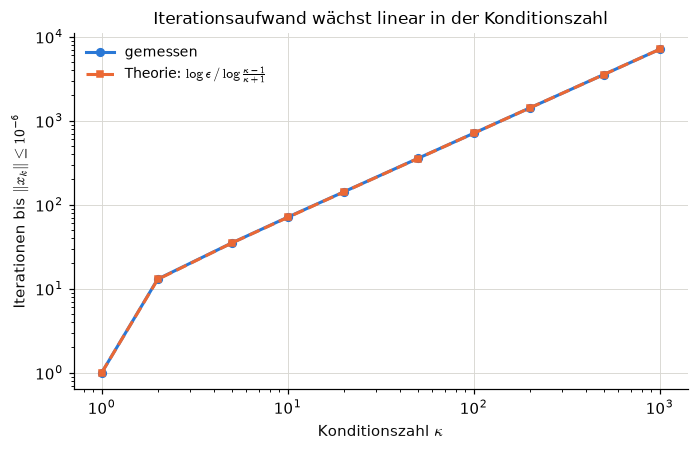

Empirische Steigung: Iterationen ~ kappa^0.999   (Theorie: Exponent 1)


In [10]:
# Iterationszahl bis ||x|| <= 1e-6 in Abhaengigkeit von kappa
kappas = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500, 1000], dtype=float)
measured, predicted = [], []

for kappa in kappas:
    _, grad_k, _ = quadratic_problem(kappa)
    eta_star = 2.0 / (1.0 + kappa)
    hist = gradient_descent(grad_k, [1.0, 1.0], lr=eta_star, n_steps=200_000, tol=0.0)
    norms = np.linalg.norm(hist, axis=1)
    reached = np.argmax(norms <= 1e-6) if np.any(norms <= 1e-6) else len(norms) - 1
    measured.append(int(reached))
    rate = (kappa - 1) / (kappa + 1)
    predicted.append(np.log(1e-6 / np.sqrt(2)) / np.log(rate) if kappa > 1 else 1.0)

fig, ax = plt.subplots()
ax.loglog(kappas, measured, marker="o", markersize=5, color=PALETTE[0], label="gemessen")
ax.loglog(kappas, predicted, marker="s", markersize=4, linestyle="--", color=PALETTE[1],
          label=r"Theorie: $\log\epsilon\,/\,\log\frac{\kappa-1}{\kappa+1}$")
ax.set_xlabel(r"Konditionszahl $\kappa$")
ax.set_ylabel(r"Iterationen bis $\|x_k\| \leq 10^{-6}$")
ax.set_title("Iterationsaufwand wächst linear in der Konditionszahl")
ax.legend(fontsize=9)
plt.show()

slope = np.polyfit(np.log(kappas[3:]), np.log(np.array(measured[3:], dtype=float)), 1)[0]
print(f"Empirische Steigung: Iterationen ~ kappa^{slope:.3f}   (Theorie: Exponent 1)")

**Abbildung 2.5** — Iterationsaufwand über der Konditionszahl im doppeltlogarithmischen
Diagramm. Die gemessene Steigung von nahezu exakt $1$ bestätigt das in Satz 5.1 hergeleitete
lineare Wachstum; Messung und geschlossene Formel stimmen über drei Größenordnungen überein.

**Praktische Konsequenz.** Merkmalsskalierung (Notebook 1, Abschnitt 6) ist nicht nur eine Frage
der Distanzmessung, sondern auch der Konditionierung: Sie bringt die Eigenwerte der Hesse-Matrix
näher zusammen und senkt damit unmittelbar die Iterationszahl. Dasselbe Ziel verfolgen
Batch-Normalisierung und adaptive Verfahren wie Adam.

<a id="6"></a>
## 6 Impulsverfahren

Das Zickzack-Verhalten entsteht, weil aufeinanderfolgende Gradienten in den stark gekrümmten
Richtungen alternieren, in den flachen dagegen gleichgerichtet bleiben. Ein gleitender Mittelwert
über die Gradienten löscht die alternierenden Anteile aus und verstärkt die konsistenten.

> **Definition 6.1 (Polyak, 1964 — Heavy-Ball).**
> $$v_{k+1} = \beta v_k - \eta\,\nabla f(x_k), \qquad x_{k+1} = x_k + v_{k+1}, \qquad \beta \in [0,1).$$
> Für $\beta = 0$ ergibt sich das gewöhnliche Gradientenverfahren.

> **Satz 6.2 (Polyak).** Für quadratisches $f$ mit Eigenwerten in $[\mu, L]$ ist das Verfahren mit
> $$\eta = \frac{4}{(\sqrt{L}+\sqrt{\mu})^2}, \qquad \beta = \Big(\frac{\sqrt{\kappa}-1}{\sqrt{\kappa}+1}\Big)^{2}$$
> asymptotisch optimal unter allen Verfahren erster Ordnung mit konstanten Koeffizienten; der
> Kontraktionsfaktor beträgt $\frac{\sqrt{\kappa}-1}{\sqrt{\kappa}+1}$.

Der Aufwand sinkt damit von $\mathcal{O}(\kappa \log \tfrac1\epsilon)$ auf
$\mathcal{O}(\sqrt{\kappa}\,\log\tfrac1\epsilon)$ — bei $\kappa = 1000$ ein Faktor von rund $30$.
Nesterovs beschleunigtes Verfahren erreicht dieselbe Ordnung und behält sie, anders als
Heavy-Ball, auch für allgemeine glatte konvexe Funktionen.

Gradientenverfahren    Iterationen bis 1e-8: 1877
Heavy-Ball (Polyak)    Iterationen bis 1e-8: 171
Nesterov               Iterationen bis 1e-8: 294


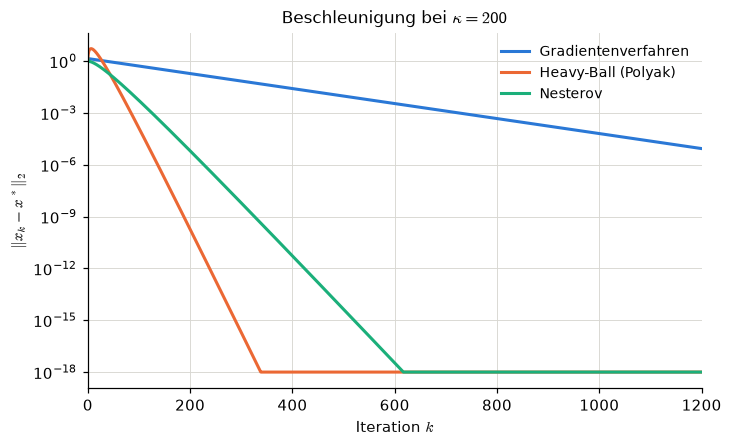


Theoretische Faktoren:  GD 0.99005   Impuls 0.86792
Erwarteter Gewinn: Faktor ~ sqrt(kappa) = 14.1


In [11]:
kappa = 200.0
f_k, grad_k, _ = quadratic_problem(kappa)
mu_k, L_k = 1.0, kappa
x_init = [1.0, 1.0]

runs = {
    "Gradientenverfahren": gradient_descent(
        grad_k, x_init, lr=2.0 / (mu_k + L_k), n_steps=3000, tol=0.0),
    "Heavy-Ball (Polyak)": gradient_descent(
        grad_k, x_init, lr=4.0 / (np.sqrt(L_k) + np.sqrt(mu_k)) ** 2,
        momentum=((np.sqrt(kappa) - 1) / (np.sqrt(kappa) + 1)) ** 2, n_steps=3000, tol=0.0),
    "Nesterov": gradient_descent(
        grad_k, x_init, lr=1.0 / L_k,
        momentum=(np.sqrt(kappa) - 1) / (np.sqrt(kappa) + 1), nesterov=True,
        n_steps=3000, tol=0.0),
}

fig, ax = plt.subplots()
for (name, hist), color in zip(runs.items(), PALETTE):
    err = np.maximum(np.linalg.norm(hist, axis=1), 1e-18)
    ax.semilogy(err, color=color, label=name)
    steps = int(np.argmax(err <= 1e-8)) if np.any(err <= 1e-8) else -1
    print(f"{name:<22} Iterationen bis 1e-8: {steps if steps > 0 else 'nicht erreicht'}")

ax.set_xlim(0, 1200)
ax.set_xlabel("Iteration $k$")
ax.set_ylabel(r"$\|x_k - x^\ast\|_2$")
ax.set_title(rf"Beschleunigung bei $\kappa = {kappa:.0f}$")
ax.legend(fontsize=9)
plt.show()

print(f"\nTheoretische Faktoren:  GD {(kappa - 1) / (kappa + 1):.5f}   "
      f"Impuls {(np.sqrt(kappa) - 1) / (np.sqrt(kappa) + 1):.5f}")
print(f"Erwarteter Gewinn: Faktor ~ sqrt(kappa) = {np.sqrt(kappa):.1f}")

**Abbildung 2.6** — Fehlerverlauf bei $\kappa = 200$. Alle drei Verfahren konvergieren
geometrisch, aber mit deutlich verschiedenen Raten; im halblogarithmischen Diagramm entspricht das
unterschiedlichen Geradensteigungen. Die Impulsvarianten erreichen die Zielgenauigkeit rund
$\sqrt{\kappa}$-mal schneller, wie von Satz 6.2 vorhergesagt. Die leichte Welligkeit der
Heavy-Ball-Kurve ist kein Artefakt: Der Kontraktionsfaktor ist dort komplex, die Iteration
beschreibt eine gedämpfte Schwingung.

<a id="7"></a>
## 7 Übungsaufgaben

**Aufgabe 2.1 (Zweite Ableitung).** Leiten Sie die zentrale Differenzenformel zweiter Ordnung
$f''(x) \approx \big(f(x+h) - 2f(x) + f(x-h)\big)/h^2$ aus der Taylor-Entwicklung her, bestimmen
Sie ihre Fehlerordnung und die optimale Schrittweite. Verifizieren Sie beides analog zu
Abbildung 2.1.

**Aufgabe 2.2 (Exakte Liniensuche).** Zeigen Sie, dass für $f(x)=\tfrac12 x^\top A x$ die
schrittweise optimale Lernrate
$\eta_k = \frac{\|g_k\|_2^2}{g_k^\top A\, g_k}$ mit $g_k = \nabla f(x_k)$ lautet. Implementieren
Sie das Verfahren und vergleichen Sie es bei $\kappa = 30$ mit der konstanten Lernrate $\eta^\ast$
aus Satz 5.1. Warum ist die exakte Liniensuche *nicht* wesentlich besser?

**Aufgabe 2.3 (Divergenzschwelle).** Bestimmen Sie experimentell für die Rosenbrock-Funktion die
größte Lernrate, bei der das Verfahren von $x_0 = (-1{,}2,\, 1)^\top$ aus noch konvergiert.
Vergleichen Sie mit $2/L$, wobei $L$ der größte Eigenwert der Hesse-Matrix entlang des Pfades ist.

**Aufgabe 2.4 (Vorkonditionierung).** Das Newton-Verfahren $x_{k+1} = x_k - \nabla^2 f(x_k)^{-1}\nabla f(x_k)$
entspricht dem steilsten Abstieg in der von $\nabla^2 f$ induzierten Norm. Zeigen Sie, dass es für
quadratisches $f$ unabhängig von $\kappa$ in einem Schritt konvergiert, und diskutieren Sie,
weshalb es im Maschinellen Lernen dennoch selten eingesetzt wird.

**Aufgabe 2.5 (Stochastischer Gradient).** Ersetzen Sie in Abschnitt 5 den exakten Gradienten
durch $\nabla f(x_k) + \xi_k$ mit $\xi_k \sim \mathcal{N}(0, \sigma^2 I)$. Zeigen Sie empirisch,
dass eine konstante Lernrate nur bis zu einem von $\sigma$ abhängigen Fehlerniveau konvergiert,
und dass eine Schrittweitenfolge $\eta_k = \eta_0/k$ dieses Niveau beseitigt.

---

## Literatur

- Boyd, S., Vandenberghe, L. (2004). *Convex Optimization.* Cambridge University Press, Kapitel 9.
- Goodfellow, I., Bengio, Y., Courville, A. (2016). *Deep Learning.* MIT Press, Kapitel 4 und 8.
- Nesterov, Y. (2004). *Introductory Lectures on Convex Optimization.* Kluwer, Kapitel 1–2.
- Nocedal, J., Wright, S. J. (2006). *Numerical Optimization.* 2. Auflage, Springer, Kapitel 3.
- Polyak, B. T. (1964). *Some methods of speeding up the convergence of iteration methods.*
  USSR Computational Mathematics and Mathematical Physics 4(5), S. 1–17.
- Squire, W., Trapp, G. (1998). *Using Complex Variables to Estimate Derivatives of Real
  Functions.* SIAM Review 40(1), S. 110–112.